# Notebook 02 - Storytelling executivo e análise não supervisionada

Notebook para gerar gráficos de clusters, drivers, drift e sensibilidade econômica.

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

for candidate in [Path.cwd().resolve(), Path.cwd().resolve().parent]:
    if (candidate / "reports" / "best_policy_by_accept_free.csv").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Nao encontrei a pasta reports a partir do diretorio atual do notebook")

REPORTS = PROJECT_ROOT / "reports"

cluster_profile = pd.read_csv(REPORTS / "unsup_cluster_profile.csv")
drivers = pd.read_csv(REPORTS / "unsup_cluster_drivers.csv")
drift = pd.read_csv(REPORTS / "unsup_monthly_drift.csv")
best_policy = pd.read_csv(REPORTS / "best_policy_by_accept_free.csv")
cluster_profile.head()

,cluster,rows,p_churn,churn_3m,fp,fn,paid_sum,total_secs,num_unq,auto_renew_rate,cancel_txn_count,share
0,0,3678624,0.148730,0.201299,0.068753,0.191537,0.172156,122094.495381,482.124396,0.294794,0.009336,0.136802
1,3,1771110,0.127308,0.053951,0.051146,0.051588,151.593155,516964.726391,1704.745175,0.840815,0.009686,0.065865
2,2,2074680,0.116552,0.042066,0.061097,0.039116,156.583811,432439.321311,1522.047293,0.790555,0.008043,0.077154
3,1,19365741,0.082908,0.018129,0.040828,0.015605,141.979177,86450.696427,345.503773,0.879304,0.007901,0.720180


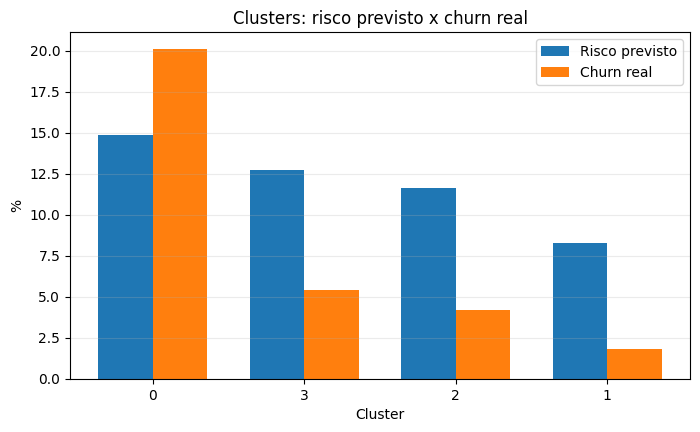

In [7]:
plt.figure(figsize=(8,4.5))
x = range(len(cluster_profile))
plt.bar([i-0.18 for i in x], cluster_profile["p_churn"]*100, width=0.36, label="Risco previsto")
plt.bar([i+0.18 for i in x], cluster_profile["churn_3m"]*100, width=0.36, label="Churn real")
plt.xticks(list(x), cluster_profile["cluster"])
plt.xlabel("Cluster")
plt.ylabel("%")
plt.title("Clusters: risco previsto x churn real")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.show()

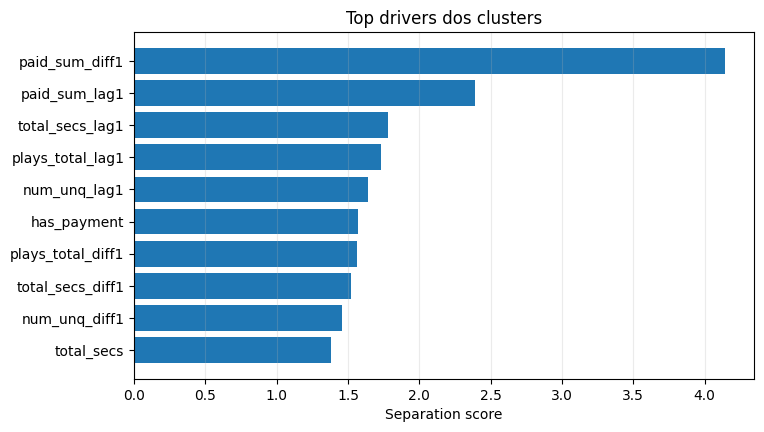

In [8]:
top_drivers = drivers.head(10).copy().sort_values("separation_score")
plt.figure(figsize=(8,4.5))
plt.barh(top_drivers["feature"], top_drivers["separation_score"])
plt.xlabel("Separation score")
plt.title("Top drivers dos clusters")
plt.grid(axis="x", alpha=0.25)
plt.show()

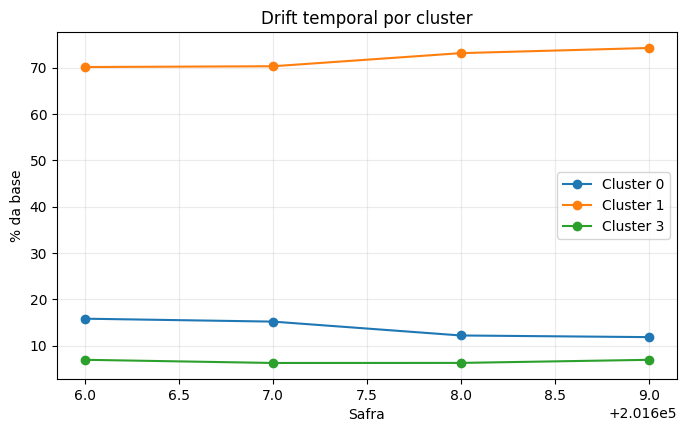

In [9]:
focus = drift[drift["cluster"].isin([0,1,3])].copy()
plt.figure(figsize=(8,4.5))
for c in sorted(focus["cluster"].unique()):
    d = focus[focus["cluster"] == c]
    plt.plot(d["safra"], d["share"]*100, marker="o", label=f"Cluster {c}")
plt.xlabel("Safra")
plt.ylabel("% da base")
plt.title("Drift temporal por cluster")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

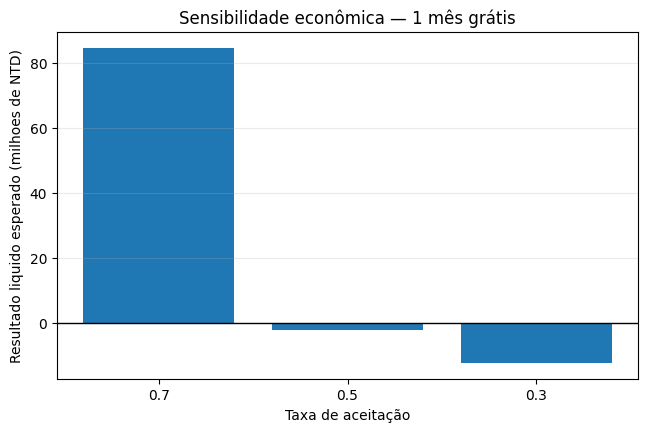

In [10]:
bp = best_policy[best_policy["free_months"] == 1].copy()
plt.figure(figsize=(7.5,4.5))
plt.bar(bp["accept_rate"].astype(str), bp["expected_net_NTD"]/1e6)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Taxa de aceitação")
plt.ylabel("Resultado liquido esperado (milhoes de NTD)")
plt.title("Sensibilidade econômica — 1 mês grátis")
plt.grid(axis="y", alpha=0.25)
plt.show()

## Leituras executivas sugeridas

- Cluster 0: maior churn real, principal publico de retencao.
- Cluster 3: risco previsto acima do churn real, sugerindo falso-alarme e necessidade de recalibracao.
- Cluster 1: maior parcela da base, baixo churn e alta taxa de auto-renew.
- Conclusao economica: 3 meses gratis e deficitario em todos os cenarios; 1 mes gratis so se torna atrativo no cenario de maior taxa de aceitacao.